# Customer Segmentation Using KMeans Clustering

##  Objective
The goal of this notebook is to segment customers into groups based on behavioural features using KMeans clustering.

## Business Context
Customer segmentation helps businesses understand different types of customers and tailor strategies accordingly.

By grouping customers based on behaviour, businesses can:
- Identify high-value customers
- Detect low-engagement customers
- Apply targeted marketing strategies

In [2]:
import pandas as pd
import numpy as np

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

rfm_scaled = pd.read_csv("../Data/processed/rfm_scaled.csv")
rfm_scaled.head()

,Unnamed: 0,customerid,recency,frequency,monetary,avg_order_value,total_items,items_per_order
0,0,12346,2.334574,-0.955214,3.707716,7.522807,3.818949,56.347343
1,1,12347,-0.905340,1.074425,1.414903,1.044160,1.332690,0.075178
2,2,12348,-0.175360,0.386304,0.720024,0.622312,1.297118,0.253529
3,3,12349,-0.735345,-0.955214,0.702287,2.449794,0.341302,0.288383
4,4,12350,2.174578,-0.955214,-0.614514,0.227101,-0.505607,-0.042254


In [3]:
features = ["recency","frequency","monetary","avg_order_value", "total_items", "items_per_order"]

X=rfm_scaled[features]

## Determine Optimal Number of Clusters

We use the Elbow Method to identify an appropriate number of clusters.

### Why this matters
Choosing too few clusters may oversimplify customer behaviour, while too many clusters may create unnecessary complexity.

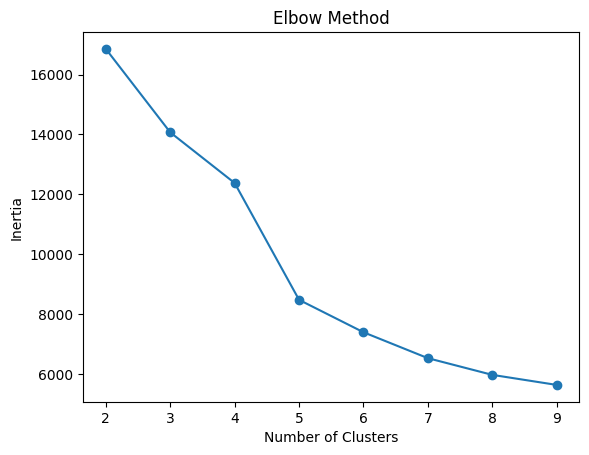

In [4]:
inertia = []
K = range(2,10)

for k in K:
    kmeans = KMeans(n_clusters =k, random_state = 42)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

plt.plot(K, inertia, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

### Insight
The elbow point suggests that an appropriate number of clusters is **k = 5**, where adding more clusters provides diminishing returns.

## Evaluate Cluster Quality

The Silhouette Score is used to assess how well-separated the clusters are.

###  Why this matters
A higher silhouette score indicates better-defined and more meaningful clusters.

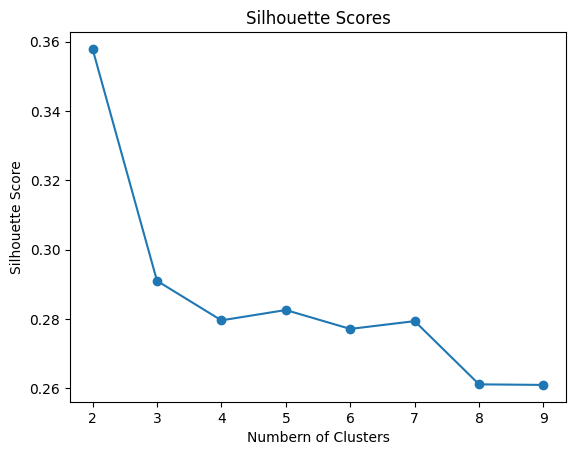

In [5]:
silhouette_scores = []

for k in K:
    kmeans = KMeans(n_clusters=k, random_state =42)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X,labels)
    silhouette_scores.append(score)

plt.plot(K, silhouette_scores,marker='o')
plt.xlabel("Numbern of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Scores")
plt.show()

## Apply KMeans Clustering

KMeans is applied using the selected number of clusters.

Each customer is assigned to a cluster based on behavioural similarity.

In [7]:
kmeans = KMeans(n_clusters=4, random_state=42)
rfm_scaled["cluster"]= kmeans.fit_predict(X)

In [8]:
rfm_raw = pd.read_csv("../Data/processed/rfm_raw.csv")
rfm_final = rfm_raw.merge(rfm_scaled[["customerid","cluster"]], on="customerid")

rfm_final.head()

,Unnamed: 0,customerid,recency,frequency,monetary,avg_order_value,total_items,items_per_order,cluster
0,0,12346,326,1,77183.60,77183.600000,74215,74215.000000,1
1,1,12347,2,7,4310.00,615.714286,2458,351.142857,1
2,2,12348,75,4,1797.24,449.310000,2341,585.250000,2
3,3,12349,19,1,1757.55,1757.550000,631,631.000000,2
4,4,12350,310,1,334.40,334.400000,197,197.000000,3


In [9]:
cluster_summary = rfm_final.groupby("cluster").mean()
cluster_summary

,Unnamed: 0,customerid,recency,frequency,monetary,avg_order_value,total_items,items_per_order
cluster,,,,,,,,
0,2336.615236,15531.277724,57.700096,1.772420,279.573319,176.716630,161.677917,107.016744
1,2070.866747,15166.702281,24.967587,12.657863,7765.472917,801.475087,4461.859544,489.800336
2,2088.898046,15190.850427,60.912088,3.087912,1138.198933,456.088143,691.401709,284.110231
3,2213.537349,15362.360241,266.284337,1.315663,318.412735,257.579429,162.767470,133.531839


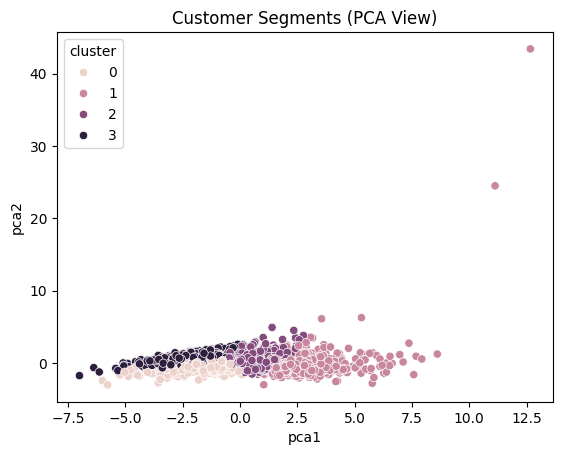

In [10]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

rfm_scaled["pca1"] = X_pca[:,0]
rfm_scaled["pca2"] = X_pca[:,1]

plt.figure()
sns.scatterplot(data = rfm_scaled, x="pca1",y="pca2", hue="cluster")
plt.title("Customer Segments (PCA View)")
plt.show()

## Business Recommendations

- High-value customers → retain with loyalty programmes
- Low-engagement customers → target with re-engagement campaigns
- Occasional customers → encourage repeat purchases
- New customers → focus on onboarding strategies

##  Key Takeaways

- Customers can be grouped into distinct behavioural segments
- RFM features effectively capture customer behaviour
- KMeans clustering provides a simple and interpretable segmentation approach

##  Next Steps

- Further refine cluster definitions
- Visualise clusters using dimensionality reduction (e.g. PCA)
- Integrate segmentation into business decision-making

## Conclusion

This notebook demonstrates how clustering can be used to segment customers based on behaviour, enabling more targeted and effective business strategies.